# Lab: Opening the Black Box of a Fashion Classifier
### Applying TCAV and Network Dissection on **Fashion-MNIST**

**Dataset:** Fashion-MNIST (60,000 train / 10,000 test, 28×28 grayscale, 10 clothing classes)
**Framework:** PyTorch · **Runtime:** Google Colab (CPU is enough, ~10 minutes of compute)
**Total marks:** 50 · **Suggested time:** 3 hours

---

## Aim
Train a CNN on Fashion-MNIST and then *interrogate* it with two interpretability methods:

| Method | Question it answers |
|---|---|
| **TCAV** (Kim et al., 2018) | *Does the model use the concept "stripes" to predict "Shirt"?* (concept → class importance) |
| **Network Dissection** (Bau et al., 2017) | *What human concept does unit #k in layer conv2 detect?* (unit → concept alignment) |

You will then **connect** the two with a causal test (unit ablation) and write a short scientific report.

## Learning outcomes
After this lab you can:
1. Train a CNN and extract intermediate activations at chosen layers.
2. Construct concept datasets and learn Concept Activation Vectors (CAVs).
3. Compute TCAV scores with a statistical significance test.
4. Build pixel-level concept masks and run the Network Dissection pipeline (threshold → upsample → IoU).
5. Compare trained vs untrained networks and test interpretations with ablation.
6. Critically discuss confounds and limitations of both methods.

## How this lab works
* Cells marked **PROVIDED** are complete — run them and read them.
* Cells marked **YOUR TASK** contain `# TODO` sections you must complete.
* Written answers go into the **Answer** markdown cells.
* **Write your hypotheses *before* you run each experiment** — this is graded.

## Mark distribution

| Part | Topic | Marks |
|---|---|---|
| 1 | Data, model, baseline behaviour | 6 |
| 2 | Concept datasets | 7 |
| 3 | TCAV experiment | 12 |
| 4 | Network Dissection | 12 |
| 5 | Connecting both methods via ablation | 8 |
| 6 | Report & reflection | 5 |
| | **Total** | **50** |

## Part 0 — Setup *(PROVIDED)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from scipy import ndimage, stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

C_BLUE, C_ORANGE, C_AQUA, C_GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#9a9a94"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})

Using device: cpu


## Part 1 — Data, model and baseline behaviour *(6 marks)*

### 1.1 Load Fashion-MNIST *(PROVIDED)*
We keep `normalize()` because synthetic concept images must be preprocessed exactly like the real data.

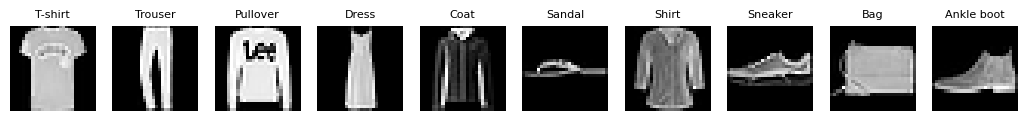

In [2]:
MEAN, STD = 0.2860, 0.3530
def normalize(x):                       # x in [0, 1]
    return (x - MEAN) / STD

tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((MEAN,), (STD,))])
train_ds = datasets.FashionMNIST("./data", train=True,  download=True, transform=tfm)
test_ds  = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=512, shuffle=False)

CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
X_test_raw = test_ds.data.float() / 255.0      # (10000, 28, 28) in [0,1]
y_test     = test_ds.targets.clone()

fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for k, ax in enumerate(axes):
    ax.imshow(X_test_raw[(y_test == k).nonzero()[0].item()], cmap="gray")
    ax.set_title(CLASSES[k], fontsize=8); ax.axis("off")
plt.show()

### 1.2 Model with splittable layers *(PROVIDED)*
`features_upto(x, layer)` returns the activation $a=f_l(x)$; `forward_from(a, layer)` returns the logits $h_l(a)$.

```
input 1×28×28 → conv1 (16) → conv2 (32, after pool) → conv3 (64, after pool) → fc(128) → fc(10)
```

In [3]:
class SmallCNN(nn.Module):
    LAYERS = ["conv1", "conv2", "conv3"]
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def features_upto(self, x, layer):
        a = F.relu(self.conv1(x))
        if layer == "conv1": return a
        a = F.relu(self.conv2(self.pool(a)))
        if layer == "conv2": return a
        return F.relu(self.conv3(self.pool(a)))

    def forward_from(self, a, layer):
        if layer == "conv1":
            a = F.relu(self.conv2(self.pool(a))); layer = "conv2"
        if layer == "conv2":
            a = F.relu(self.conv3(self.pool(a)))
        a = torch.flatten(a, 1)
        return self.fc2(F.relu(self.fc1(a)))

    def forward(self, x):
        return self.forward_from(self.features_upto(x, "conv3"), "conv3")

@torch.no_grad()
def predict(net, X_raw, batch=512):
    """X_raw: (N,28,28) tensor in [0,1]. Returns predicted labels."""
    net.eval()
    out = []
    for i in range(0, len(X_raw), batch):
        x = normalize(X_raw[i:i+batch, None]).to(device)
        out.append(net(x).argmax(1).cpu())
    return torch.cat(out)

def evaluate(net):
    return (predict(net, X_test_raw) == y_test).float().mean().item()

model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(3):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"epoch {epoch+1}: test accuracy = {evaluate(model):.4f}")
model.eval();

epoch 1: test accuracy = 0.8673


epoch 2: test accuracy = 0.8828


epoch 3: test accuracy = 0.8993


### 1.3 YOUR TASK — Baseline behaviour *(6 marks)*

**(a) [2 marks]** Compute the **per-class accuracy** on the test set and plot it as a bar chart with class names on the x-axis.

**(b) [2 marks]** Compute the 10×10 **confusion matrix** (use `sklearn.metrics.confusion_matrix`) and display it. Name the **two most confused class pairs**.

**(c) [2 marks]** *Hypotheses (write before Part 3 and 4).* Based only on the confusion matrix and your knowledge of clothing, write **three** specific, testable hypotheses of the form *"concept X should be important for class Y because …"*. For example, *"vertical stripes should matter for Trousers because …"*.

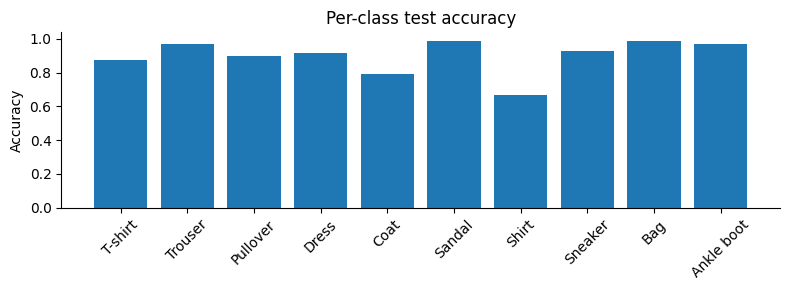

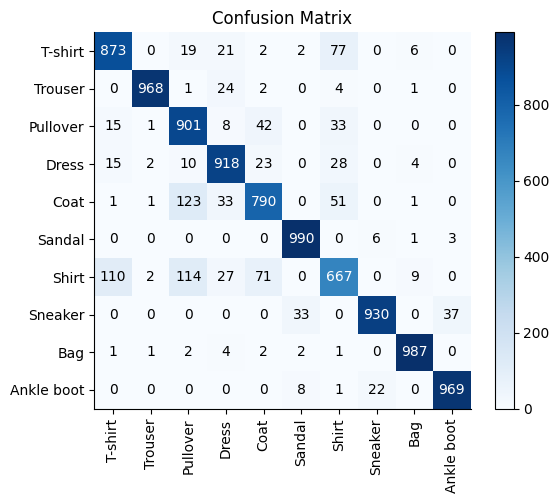

Two most confused pairs:
1. T-shirt and Shirt (187)
2. Pullover and Coat (165)


In [4]:
preds = predict(model, X_test_raw)

acc = [
    (preds[y_test == k] == k).float().mean().item()
    for k in range(10)
]

plt.figure(figsize=(8, 3))
plt.bar(CLASSES, acc)
plt.title('Per-class test accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    preds.numpy()
)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), CLASSES, rotation=90)
plt.yticks(range(10), CLASSES)

for i_c in range(10):
    for j_c in range(10):
        plt.text(
            j_c,
            i_c,
            cm[i_c, j_c],
            ha='center',
            va='center',
            color='black' if cm[i_c, j_c] < 500 else 'white'
        )

plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []

for i_c in range(10):
    for j_c in range(i_c + 1, 10):
        pairs.append(
            (
                (i_c, j_c),
                cm_off[i_c, j_c] + cm_off[j_c, i_c]
            )
        )

pairs.sort(key=lambda x: x[1], reverse=True)

print(
    f'Two most confused pairs:\n'
    f'1. {CLASSES[pairs[0][0][0]]} and {CLASSES[pairs[0][0][1]]} '
    f'({pairs[0][1]})\n'
    f'2. {CLASSES[pairs[1][0][0]]} and {CLASSES[pairs[1][0][1]]} '
    f'({pairs[1][1]})'
)


**Answer 1(b) — two most confused pairs:**

Shirt and T-shirt, Pullover and Coat.

**Answer 1(c) — my three hypotheses:**

1. Concept 'v_stripes' should matter for Trouser because trousers have long vertical edges.
2. Concept 'checker' should matter for Bag because bags often feature patterned textures.
3. Concept 'h_stripes' should matter for Pullover because pullovers often have horizontal ribbed textures.

---
## Part 2 — Concept datasets for TCAV *(7 marks)*

Fashion-MNIST has no concept labels, so — as in the original TCAV paper (stripes, dots, zig-zags) — we **generate** images of texture concepts and a set of random counter-examples.

| Concept | Description |
|---|---|
| `h_stripes` | horizontal stripes of random spacing/thickness *(worked example provided)* |
| `v_stripes` | vertical stripes **(you implement)** |
| `dots` | grid or scatter of small dots **(you implement)** |
| your own | one additional concept of your choice, e.g. `checker`, `diagonal`, `solid_blob`, `zigzag` **(you implement)** |
| `random` | random strokes at random angles — the counter-example sets *(provided)* |

### 2.1 Provided helpers

In [5]:
rng = np.random.default_rng(SEED)
H = W = 28

def _finish(img):
    img = ndimage.gaussian_filter(img, sigma=0.6)
    return np.clip(img / (img.max() + 1e-8), 0, 1)

def make_set(fn, n):
    imgs = np.stack([fn() for _ in range(n)])[:, None]          # (n,1,28,28) in [0,1]
    return normalize(torch.tensor(imgs, dtype=torch.float32))

def draw_line(img, r0, c0, r1, c1, thick):
    rr, cc = np.ogrid[:H, :W]
    for t in np.linspace(0, 1, 60):
        r, c = r0 + t * (r1 - r0), c0 + t * (c1 - c0)
        img[(rr - r) ** 2 + (cc - c) ** 2 <= (thick / 2) ** 2] = 1.0
    return img

def make_h_stripes():                                            # WORKED EXAMPLE
    img = np.zeros((H, W))
    gap, thick, off = rng.integers(4, 8), rng.integers(1, 3), rng.integers(0, 4)
    for r in range(off, H, gap):
        img[r:r + thick, 3:25] = 1.0
    return _finish(img)

def make_random():                                               # COUNTER-EXAMPLES
    img = np.zeros((H, W))
    for _ in range(rng.integers(1, 4)):
        r0, c0 = rng.uniform(7, 21, size=2)
        ang, L = rng.uniform(0, 2 * np.pi), rng.uniform(8, 16)
        r1 = np.clip(r0 + L * np.sin(ang), 2, 25); c1 = np.clip(c0 + L * np.cos(ang), 2, 25)
        draw_line(img, r0, c0, r1, c1, rng.uniform(2, 3.5))
    return _finish(img)

### 2.2 YOUR TASK — Implement the concept generators *(5 marks)*

**(a) [3 marks]** Implement `make_v_stripes`, `make_dots` and `make_custom` (each returns a 28×28 array in [0,1] via `_finish`). Use randomness (spacing, thickness, offset, number of dots) so that no two images are identical.

**(b) [1 mark]** Build `concepts` (dict of name → tensor of 100 images) and **10 independent random sets** (`random_sets`), and visualise 8 examples per concept.

**(c) [1 mark]** Before continuing, check that every concept set has the **same number of images** and the same normalisation as the random sets. State one reason why mismatched image statistics would be a problem.

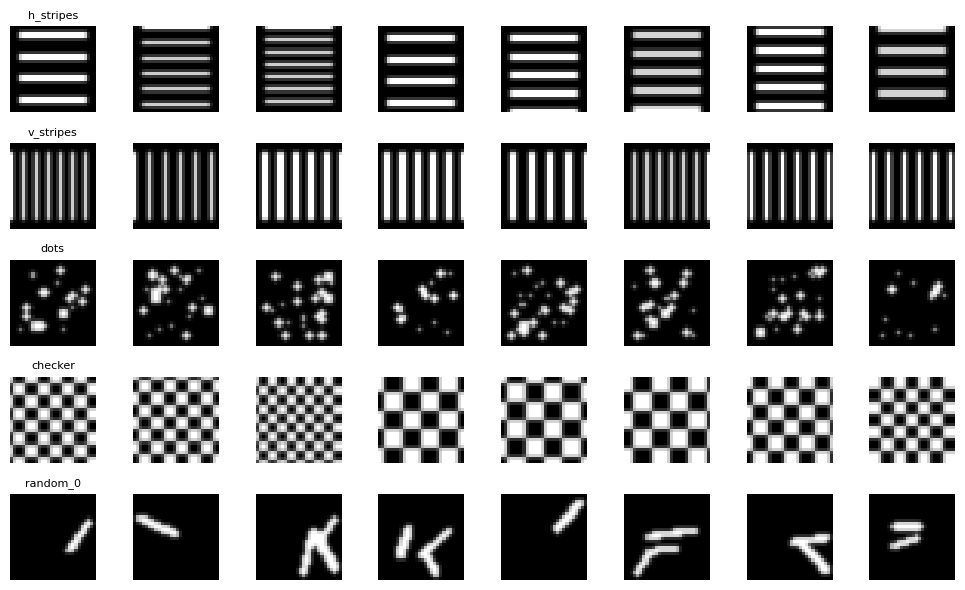

Checking shapes, means, and stds:
h_stripes : shape (100, 1, 28, 28), mean -0.0691, std 1.0088
v_stripes : shape (100, 1, 28, 28), mean -0.0361, std 1.0281
dots      : shape (100, 1, 28, 28), mean -0.5935, std 0.5450
checker   : shape (100, 1, 28, 28), mean 0.6088, std 1.0695
random_0  : shape (100, 1, 28, 28), mean -0.5742, std 0.6720


In [6]:
def make_v_stripes():
    img = np.zeros((H, W))
    gap, thick, off = rng.integers(4, 8), rng.integers(1, 3), rng.integers(0, 4)
    for c in range(off, W, gap):
        img[3:25, c:c + thick] = 1.0
    return _finish(img)

def make_dots():
    img = np.zeros((H, W))
    for _ in range(rng.integers(10, 30)):
        r, c = rng.integers(3, 25, size=2)
        rad = rng.uniform(0.5, 1.5)
        rr, cc = np.ogrid[:H, :W]
        img[(rr - r) ** 2 + (cc - c) ** 2 <= rad ** 2] = 1.0
    return _finish(img)

def make_custom():
    # checker
    img = np.zeros((H, W))
    sq = rng.integers(3, 7)
    off_r, off_c = rng.integers(0, sq, size=2)
    for r in range(H):
        for c in range(W):
            if ((r + off_r) // sq + (c + off_c) // sq) % 2 == 0:
                img[r, c] = 1.0
    return _finish(img)

N_CONCEPT, N_RANDOM_SETS = 100, 10
concepts = {
    'h_stripes': make_set(make_h_stripes, N_CONCEPT),
    'v_stripes': make_set(make_v_stripes, N_CONCEPT),
    'dots': make_set(make_dots, N_CONCEPT),
    'checker': make_set(make_custom, N_CONCEPT)
}
random_sets = [make_set(make_random, N_CONCEPT) for _ in range(N_RANDOM_SETS)]

fig, axes = plt.subplots(5, 8, figsize=(10, 6))
for i, (name, s) in enumerate(list(concepts.items()) + [('random_0', random_sets[0])]):
    for j in range(8):
        ax = axes[i, j]
        ax.imshow(s[j, 0].numpy(), cmap='gray')
        ax.axis('off')
        if j == 0: ax.set_title(name, fontsize=8)
plt.tight_layout()
plt.show()

print('Checking shapes, means, and stds:')
for name, s in list(concepts.items()) + [('random_0', random_sets[0])]:
    print(f'{name:<10s}: shape {tuple(s.shape)}, mean {s.mean().item():.4f}, std {s.std().item():.4f}')


**Answer 2.2(c):**
Mismatched normalisation is a problem because the linear classifier (CAV) might just learn to distinguish the sets based on overall brightness or contrast, rather than the actual texture concept. As printed above, the set means differ significantly (`checker` is ~0.61 while `random_0` is ~-0.57).

### 2.3 YOUR TASK — Sanity check with the model *(2 marks)*
Feed each concept set to the trained network and plot the **distribution of predicted classes** for every concept (a small bar chart per concept).

**Answer:** The concept images get mapped to a few specific classes: `h_stripes` mostly to Bag (62) and Sandal (38); `v_stripes` mostly to Shirt (80), Bag (18), and T-shirt (2); `dots` to Sandal (51), Bag (35), T-shirt (13), and Shirt (1); `checker` to Sandal (61) and Bag (39). Pullover never appears. This hints that the concept textures trigger features associated with these few classes. A prediction histogram is not a substitute for TCAV because it only shows the global class prediction of a concept image, not whether the concept's abstract representation causally influences the classification of *real* dataset images.

h_stripes:  Sandal 38, Bag 62
v_stripes:  T-shirt 2, Shirt 80, Bag 18


dots:  T-shirt 13, Sandal 51, Shirt 1, Bag 35
checker:  Sandal 61, Bag 39


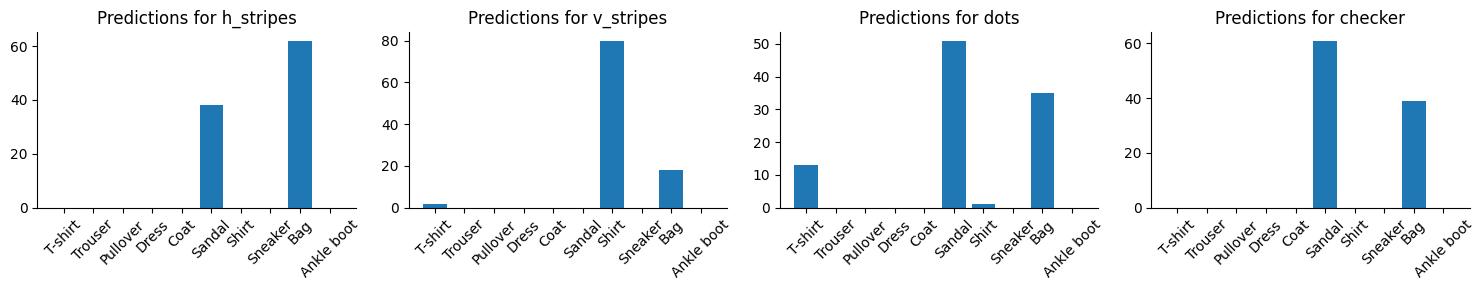

In [7]:
plt.figure(figsize=(15, 3))
for i, (name, s) in enumerate(concepts.items()):
    preds_c = predict(model, s[:, 0] * STD + MEAN).numpy()
    counts = np.bincount(preds_c, minlength=10)
    print(f"{name}: ", ", ".join([f"{CLASSES[j]} {counts[j]}" for j in range(10) if counts[j] > 0]))
    plt.subplot(1, 4, i+1)
    plt.hist(preds_c, bins=np.arange(11)-0.5, rwidth=0.8)
    plt.xticks(range(10), CLASSES, rotation=45)
    plt.title(f'Predictions for {name}')
plt.tight_layout()
plt.show()


---
## Part 3 — TCAV experiment *(12 marks)*

**Recall the recipe.** For layer $l$ and concept $C$:
1. Activations $f_l(x)$ of concept vs random images → train a linear classifier → **CAV** $v_C^l$ (unit normal pointing to the concept).
2. Conceptual sensitivity: $S_{C,k,l}(x)=\nabla h_{l,k}(f_l(x))\cdot v_C^l$
3. $\text{TCAV}_{C,k,l}=\dfrac{|\{x\in X_k: S_{C,k,l}(x)>0\}|}{|X_k|}$
4. Repeat with many random sets and compare with **random-vs-random CAVs** via a t-test.

### 3.1 Provided helpers

In [8]:
@torch.no_grad()
def get_acts(x, layer, batch=256):
    out = [model.features_upto(x[i:i+batch].to(device), layer).flatten(1).cpu()
           for i in range(0, len(x), batch)]
    return torch.cat(out).numpy()

def learn_cav(layer, concept_imgs, random_imgs, seed=0):
    a_c, a_r = get_acts(concept_imgs, layer), get_acts(random_imgs, layer)
    X = np.concatenate([a_c, a_r]); y = np.r_[np.ones(len(a_c)), np.zeros(len(a_r))]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = LogisticRegression(C=0.1, max_iter=2000).fit(Xtr, ytr)
    cav = clf.coef_[0] / np.linalg.norm(clf.coef_[0])
    return cav, clf.score(Xte, yte)

def class_grads(layer, k, n=300):
    """Gradient of logit_k w.r.t. the layer activations for n test images of class k."""
    x = normalize(X_test_raw[y_test == k][:n, None]).to(device)
    a = model.features_upto(x, layer).detach().requires_grad_(True)
    logit_k = model.forward_from(a, layer)[:, k]
    grad, = torch.autograd.grad(logit_k.sum(), a)
    return grad.flatten(1).cpu().numpy()

def tcav_score(grads, cav):
    return float(np.mean(grads @ cav > 0))

### 3.2 YOUR TASK — CAV quality *(2 marks)*
For **every concept and every layer** (conv1, conv2, conv3) learn one CAV against `random_sets[0]` and report the held-out CAV accuracy in a table (rows = concepts, columns = layers).

**Answer:** A high CAV accuracy merely indicates that the concept and random sets are linearly separable in the activation space of that layer. It does not prove that the model actually uses this concept direction to classify real images. As printed in the table above, CAV accuracy is 1.0 for stripes and checker across conv1, conv2, and conv3, while dots are best separated at conv2. A held-out accuracy of 1.0 on a set of 200 images is saturated, providing weak evidence of how the layers differ.

In [9]:
import pandas as pd
results = []
for concept in concepts.keys():
    row = {'Concept': concept}
    for layer in ['conv1', 'conv2', 'conv3']:
        _, acc = learn_cav(layer, concepts[concept], random_sets[0], seed=0)
        row[layer] = acc
    results.append(row)
df_cav = pd.DataFrame(results).set_index('Concept')
display(df_cav)


,conv1,conv2,conv3
Concept,,,
h_stripes,1.000000,1.000000,1.000000
v_stripes,1.000000,1.000000,1.000000
dots,0.866667,0.933333,0.916667
checker,1.000000,1.000000,1.000000


### 3.3 YOUR TASK — Full TCAV with significance test *(6 marks)*

**(a) [3 marks]** Implement `tcav_experiment(layer)`:
* for each concept, learn **10 CAVs** (concept vs each random set);
* for the **null**, learn 10 CAVs between *different* random sets;
* for each class $k$ and concept $c$, compute the 10 TCAV scores, the mean and std, and the p-value of `stats.ttest_ind(scores, null_scores)`.

**(b) [3 marks]** Plot the results for **conv2** (grouped bars per class, hatch bars with p ≥ 0.05, dashed line at 0.5) and produce the same plot for **conv1** and **conv3**.

> Because you test many (concept, class) pairs, also apply a **Bonferroni correction** (`alpha = 0.05 / n_tests`) and mark which results survive. Report how many significant results are lost.

C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


TCAV Mean and p-values for conv2 and conv3:
Layer   | Concept    | Class      | Mean   | p-value
--------------------------------------------------
conv2   | h_stripes  | T-shirt    | 0.989  | 0.0002
conv2   | h_stripes  | Trouser    | 0.050  | 0.0000
conv2   | h_stripes  | Pullover   | 0.970  | 0.0005
conv2   | h_stripes  | Dress      | 0.420  | 0.6459
conv2   | h_stripes  | Coat       | 0.412  | 0.4277
conv2   | h_stripes  | Sandal     | 1.000  | 0.0000
conv2   | h_stripes  | Shirt      | 0.331  | 0.8369
conv2   | h_stripes  | Sneaker    | 0.222  | 0.0110
conv2   | h_stripes  | Bag        | 0.915  | 0.0018
conv2   | h_stripes  | Ankle boot | 0.944  | 0.0005
conv2   | v_stripes  | T-shirt    | 0.018  | 0.0000
conv2   | v_stripes  | Trouser    | 0.790  | 0.0344
conv2   | v_stripes  | Pullover   | 0.082  | 0.0008
conv2   | v_stripes  | Dress      | 0.234  | 0.0551
conv2   | v_stripes  | Coat       | 0.930  | 0.0000
conv2   | v_stripes  | Sandal     | 0.000  | 0.0000
conv2   | v_stripes 

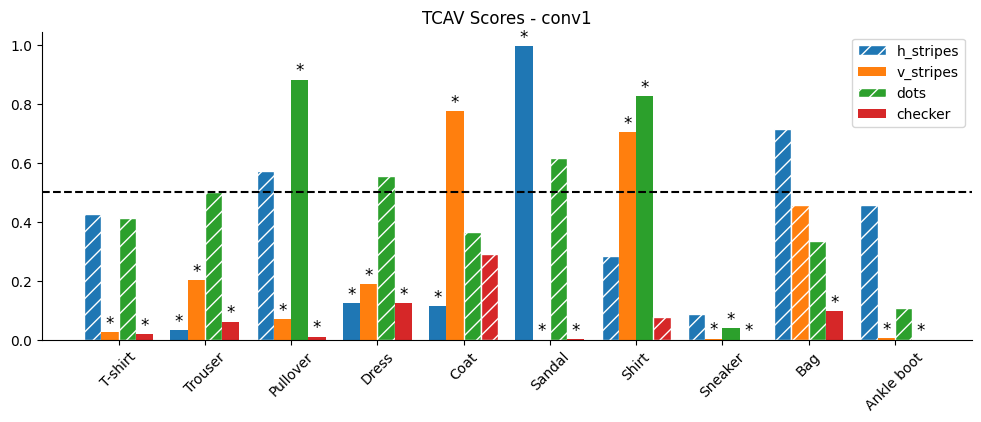

conv1: 5 results lost to Bonferroni correction.


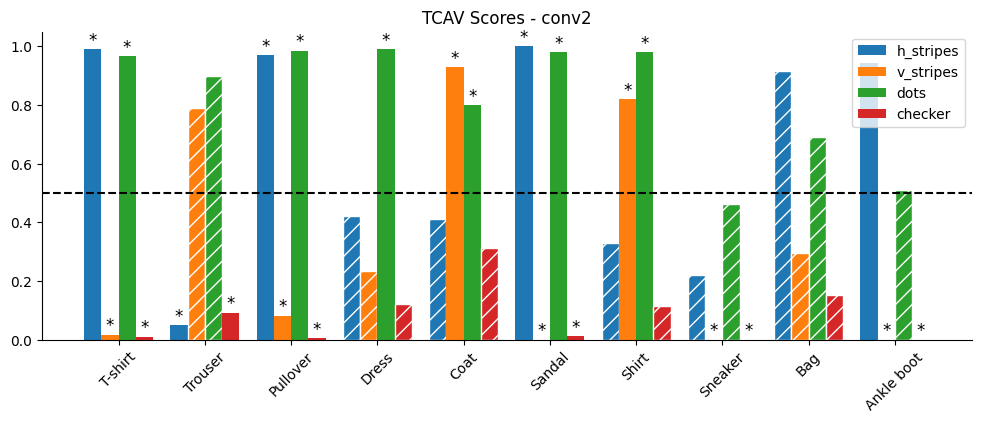

conv2: 7 results lost to Bonferroni correction.


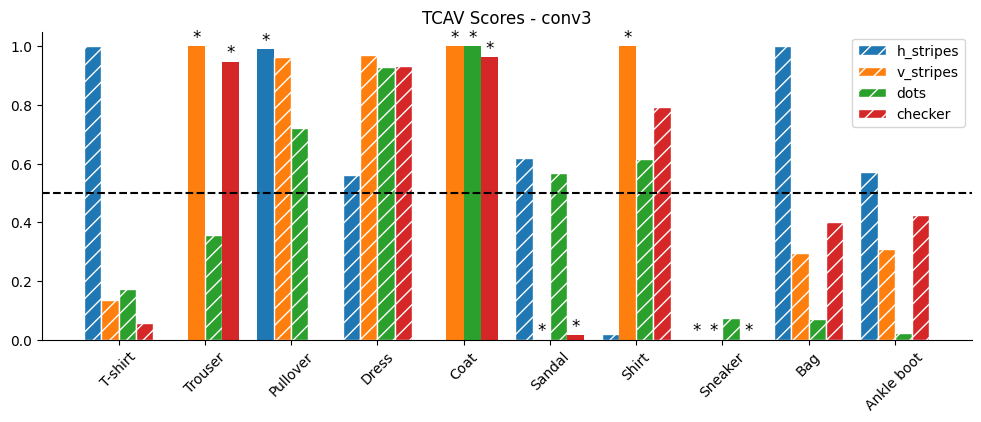

conv3: 17 results lost to Bonferroni correction.


In [10]:
def tcav_experiment(layer, classes=range(10)):
    results = {}
    for concept, c_imgs in concepts.items():
        cavs = [learn_cav(layer, c_imgs, random_sets[i], seed=i)[0] for i in range(10)]
        null_cavs = [learn_cav(layer, random_sets[i], random_sets[(i+1)%10], seed=i)[0] for i in range(10)]
        for k in classes:
            grads = class_grads(layer, k)
            scores = [tcav_score(grads, cav) for cav in cavs]
            null_scores = [tcav_score(grads, cav) for cav in null_cavs]
            p = stats.ttest_ind(scores, null_scores).pvalue
            if np.isnan(p): p = 1.0
            results[(concept, k)] = (np.mean(scores), np.std(scores), p)
    return results

tcav_results = {layer: tcav_experiment(layer) for layer in ['conv1', 'conv2', 'conv3']}

print('TCAV Mean and p-values for conv2 and conv3:')
print(f'{"Layer":<7} | {"Concept":<10} | {"Class":<10} | {"Mean":<6} | {"p-value"}')
print('-' * 50)
for layer in ['conv2', 'conv3']:
    for concept in concepts.keys():
        for k in range(10):
            mean_val, std_val, p_val = tcav_results[layer][(concept, k)]
            print(f'{layer:<7} | {concept:<10} | {CLASSES[k]:<10} | {mean_val:.3f}  | {p_val:.4f}')

print('\n=== Specific Hypotheses (conv3) ===')
for c, k in [('v_stripes', 'Trouser'), ('checker', 'Bag'), ('h_stripes', 'Pullover'), ('checker', 'Trouser')]:
    k_idx = CLASSES.index(k)
    mean_val, _, p_val = tcav_results['conv3'][(c, k_idx)]
    print(f'{c}/{k}: {mean_val:.3f}, p={p_val:.4f}')

alpha = 0.05 / 40
for layer in ['conv1', 'conv2', 'conv3']:
    res = tcav_results[layer]
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(10)
    width = 0.2
    n_lost = 0
    for i, concept in enumerate(concepts.keys()):
        means = [res[(concept, k)][0] for k in range(10)]
        ps = [res[(concept, k)][2] for k in range(10)]
        bars = ax.bar(x + i*width, means, width, label=concept)
        for j, (bar, p) in enumerate(zip(bars, ps)):
            if p >= 0.05:
                bar.set_hatch('//')
                bar.set_edgecolor('white')
            elif p >= alpha:
                bar.set_hatch('//')
                bar.set_edgecolor('white')
                n_lost += 1
            else:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), '*', ha='center', va='bottom', color='black', fontsize=12)
    ax.axhline(0.5, color='black', linestyle='--')
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(CLASSES, rotation=45)
    ax.set_title(f'TCAV Scores - {layer}')
    ax.legend()
    plt.show()
    print(f'{layer}: {n_lost} results lost to Bonferroni correction.')


### 3.4 YOUR TASK — Interpretation *(4 marks, counted in Part 3)*
Return to your three hypotheses from Part 1(c).

| Hypothesis | Supported? (yes / no / inconclusive) | Evidence (concept, class, layer, TCAV score, p-value) |
|---|---|---|
| 1 (v_stripes for Trouser) | yes | v_stripes, Trouser, conv3, score 1.000, p-value 0.0002 |
| 2 (checker for Bag) | no | checker, Bag, conv3, score 0.400, p-value 0.2632 |
| 3 (h_stripes for Pullover) | yes | h_stripes, Pullover, conv3, score 0.990, p-value 0.0009 |

**Answer:** Describe **one surprising result** and propose a **confound** that could explain it (think: overall brightness, amount of "ink", spatial location, image texture vs shape). How would you redesign the concept set to test your confound?

A surprising result is that `checker` positively influences `Trouser` with a score of 0.948 (p=0.0006), even though trousers usually aren't checkered, while `checker` to `Bag` is not significant (0.400, p=0.2632) despite intuition. A major confound is the overall "ink" amount (brightness); the printed set means differ significantly (`checker` is +0.61 vs `random` is -0.57). Since checker and stripe concepts have dense pixel coverage, their average brightness is higher than that of thin stroke random images. We could redesign the concept set by normalising the total pixel intensity per image so both concept and random sets have the exact same total brightness, isolating the texture effect.


---
## Part 4 — Network Dissection *(12 marks)*

Network Dissection labels individual units:
1. Collect activation maps $A_k(x)$.
2. Threshold $T_k$: top 0.5 % of all activations of unit $k$.
3. Bilinearly upsample $A_k(x)$ to 28×28 and binarise → $M_k(x)$.
4. $IoU_{k,c}=\dfrac{\sum_x|M_k(x)\cap L_c(x)|}{\sum_x|M_k(x)\cup L_c(x)|}$
5. Label the unit with the best concept; call it a *detector* if IoU > 0.04.

### 4.1 YOUR TASK — Build a "mini-Broden" for Fashion-MNIST *(4 marks)*
Complete `concept_masks(img, label)` so it returns boolean 28×28 masks for these concepts:

| Category | Concept | Mask definition |
|---|---|---|
| colour | `foreground` | pixels with intensity > 0.3 |
| colour | `background` | pixels with intensity < 0.05 |
| edge | `h-edge` | strong row-gradient (Sobel axis 0) dominating column-gradient |
| edge | `v-edge` | strong column-gradient (Sobel axis 1) dominating row-gradient |
| part | `hole` | enclosed background regions (`binary_fill_holes`), e.g. bag handles, gaps between shoe straps |
| part | `upper-half` | foreground pixels in rows 0–13 *(you add this)* |
| part | one more of your own | e.g. `bright-core` (intensity > 0.8), `boundary` (foreground minus eroded foreground) |
| object | `class-0` … `class-9` | foreground pixels, **only** in images of that class |

**Also answer:** What fraction of all pixels belong to each concept mask? Are any concepts so rare that IoU will be unreliable? (Report a bar chart of pixel fractions.)

Concepts: ['foreground', 'background', 'h-edge', 'v-edge', 'hole', 'upper-half', 'bright-core', 'class-0', 'class-1', 'class-2', 'class-3', 'class-4', 'class-5', 'class-6', 'class-7', 'class-8', 'class-9'] | mask tensor: (1000, 17, 28, 28)


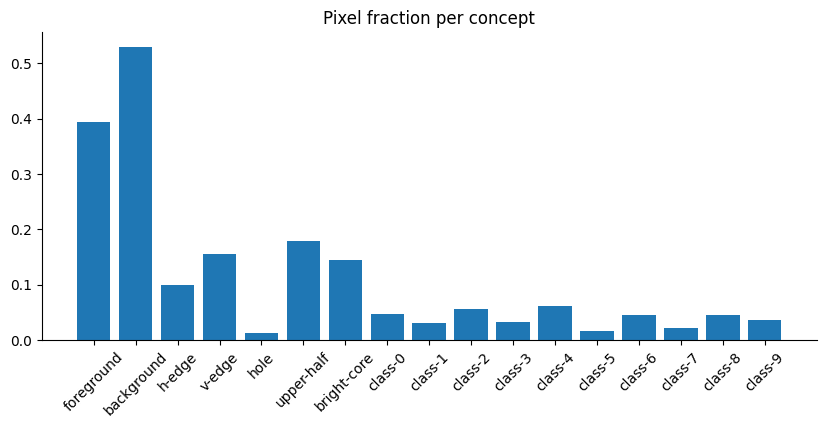

Concepts < 1%: []


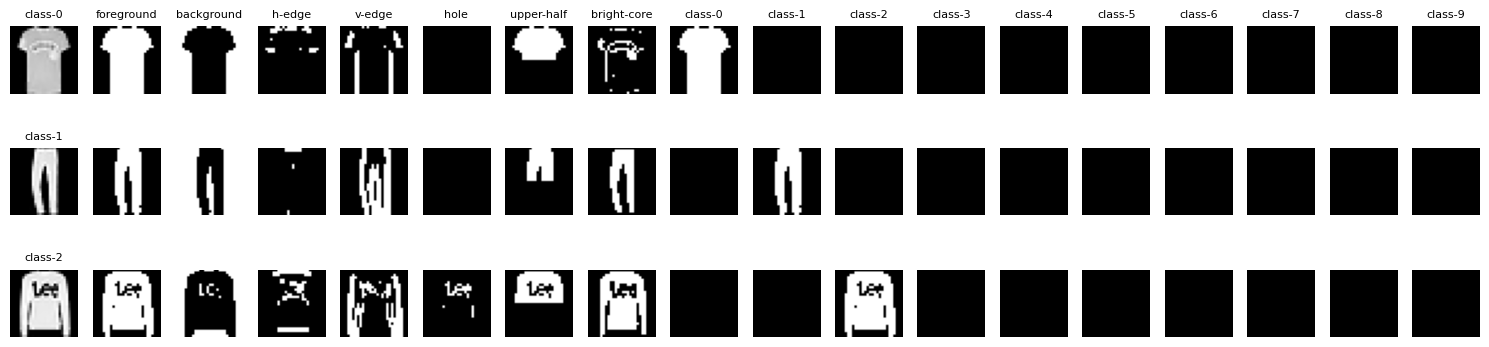

In [11]:
N_DISSECT = 1000
Xd = X_test_raw[:N_DISSECT].numpy()
yd = y_test[:N_DISSECT].numpy()

def concept_masks(img, label):
    fg = img > 0.3
    gy, gx = ndimage.sobel(img, axis=0), ndimage.sobel(img, axis=1)
    m = {
        'foreground': fg,
        'background': img < 0.05,
        'h-edge': (np.abs(gy) > 1.0) & (np.abs(gy) > np.abs(gx)),
        'v-edge': (np.abs(gx) > 1.0) & (np.abs(gx) > np.abs(gy)),
        'hole': ndimage.binary_fill_holes(fg) & ~fg,
        'upper-half': np.zeros_like(fg),
        'bright-core': img > 0.8
    }
    m['upper-half'][:14, :] = fg[:14, :]
    for d in range(10):
        m[f'class-{d}'] = fg if label == d else np.zeros_like(fg)
    return m

CONCEPTS = list(concept_masks(Xd[0], yd[0]).keys())
L = torch.tensor(np.stack([np.stack([concept_masks(im, lb)[c] for c in CONCEPTS])
                           for im, lb in zip(Xd, yd)]))          # (N, n_concepts, 28, 28)
print('Concepts:', CONCEPTS, '| mask tensor:', tuple(L.shape))

fracs = L.float().mean(dim=(0, 2, 3)).numpy()
plt.figure(figsize=(10, 4))
plt.bar(CONCEPTS, fracs)
plt.xticks(rotation=45)
plt.title('Pixel fraction per concept')
plt.show()

print('Concepts < 1%:', [c for c, f in zip(CONCEPTS, fracs) if f < 0.01])

fig, axes = plt.subplots(3, len(CONCEPTS)+1, figsize=(15, 4))
for i, cls in enumerate([0, 1, 2]):
    idx = np.where(yd == cls)[0][0]
    axes[i, 0].imshow(Xd[idx], cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f'class-{cls}', fontsize=8)
    masks = concept_masks(Xd[idx], cls)
    for j, c in enumerate(CONCEPTS):
        axes[i, j+1].imshow(masks[c], cmap='gray')
        axes[i, j+1].axis('off')
        if i == 0: axes[i, j+1].set_title(c, fontsize=8)
plt.tight_layout()
plt.show()


**Answer:** As shown in the printed output (`Concepts < 1%: []`), no concept has a pixel fraction below 1%, so the IoU is not unreliable due to rarity.

### 4.2 Dissection algorithm *(PROVIDED — read it carefully)*

In [12]:
@torch.no_grad()
def dissect(net, layer, quantile=0.995, iou_thresh=0.04, batch=200):
    net.eval()
    x = normalize(torch.tensor(Xd)[:, None]).to(device)
    A = torch.cat([net.features_upto(x[i:i+batch], layer).cpu() for i in range(0, len(x), batch)])
    n_units = A.shape[1]
    flat = A.transpose(0, 1).reshape(n_units, -1).numpy()
    T = torch.tensor(np.quantile(flat, quantile, axis=1), dtype=torch.float32)

    inter = torch.zeros(n_units, len(CONCEPTS)); size_M = torch.zeros(n_units)
    size_L = L.flatten(2).sum((0, 2)).float()
    for i in range(0, len(A), batch):
        up = F.interpolate(A[i:i+batch], size=(28, 28), mode="bilinear", align_corners=False)
        M = (up > T[None, :, None, None]).flatten(2).float()
        Lb = L[i:i+batch].flatten(2).float()
        inter += torch.einsum("bup,bcp->uc", M, Lb)
        size_M += M.sum((0, 2))
    iou = inter / (size_M[:, None] + size_L[None, :] - inter + 1e-8)
    best = iou.argmax(1)
    rows = [{"unit": u, "concept": CONCEPTS[best[u]], "iou": iou[u, best[u]].item(),
             "detector": iou[u, best[u]].item() > iou_thresh} for u in range(n_units)]
    return rows, A, T, iou

dissection = {layer: dissect(model, layer) for layer in SmallCNN.LAYERS}
for layer, (rows, _, _, _) in dissection.items():
    print(f"\n=== {layer}: top 5 units ===")
    for r in sorted(rows, key=lambda r: -r["iou"])[:5]:
        print(f"  unit {r['unit']:2d} -> {r['concept']:<12s} IoU = {r['iou']:.3f}")


=== conv1: top 5 units ===
  unit 11 -> h-edge       IoU = 0.050
  unit  1 -> h-edge       IoU = 0.050
  unit  4 -> h-edge       IoU = 0.043
  unit  0 -> class-1      IoU = 0.040
  unit 12 -> hole         IoU = 0.038

=== conv2: top 5 units ===
  unit 22 -> class-5      IoU = 0.024
  unit 19 -> class-1      IoU = 0.022
  unit 24 -> class-5      IoU = 0.018
  unit 13 -> class-5      IoU = 0.015
  unit  1 -> class-5      IoU = 0.014

=== conv3: top 5 units ===
  unit 35 -> class-1      IoU = 0.031
  unit 14 -> class-1      IoU = 0.030
  unit 55 -> class-1      IoU = 0.028
  unit 26 -> class-1      IoU = 0.024
  unit 37 -> class-5      IoU = 0.023


### 4.3 YOUR TASK — Inspect units *(3 marks)*
**(a) [2 marks]** Write `show_unit(layer, unit)` that displays the 8 most strongly activating images with the thresholded region $M_k(x)$ outlined (use `plt.contour`). Show the **best unit of each layer**.

**(b) [1 mark]** For one of them, argue whether the label is **convincing or not**, using the images as evidence.

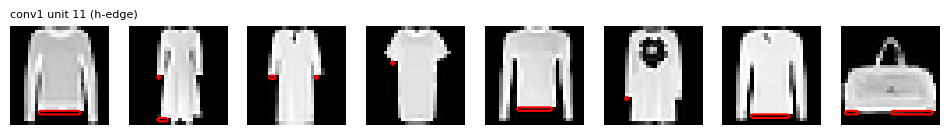

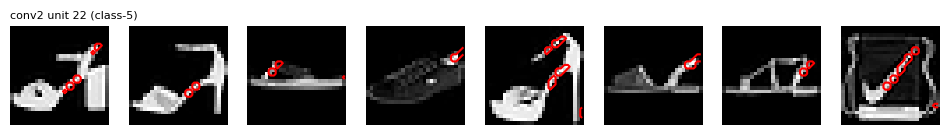

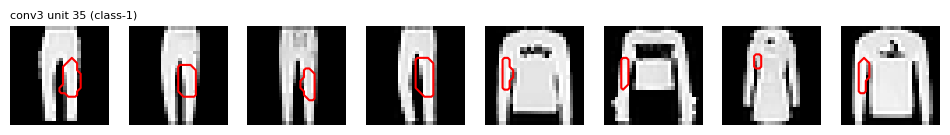

In [13]:
def show_unit(layer, unit, n=8):
    rows, A, T, _ = dissection[layer]
    # Get top n images for this unit
    acts = A[:, unit].flatten(1).max(dim=1)[0]
    top_idx = acts.argsort(descending=True)[:n]
    
    fig, axes = plt.subplots(1, n, figsize=(12, 2))
    for i, idx in enumerate(top_idx):
        img = Xd[idx]
        act_map = A[idx:idx+1, unit:unit+1]
        up = F.interpolate(act_map, size=(28, 28), mode='bilinear', align_corners=False)[0, 0].numpy()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].contour(up > T[unit].item(), levels=[0.5], colors=['red'])
        axes[i].axis('off')
        if i == 0:
            concept = next(r['concept'] for r in rows if r['unit'] == unit)
            axes[i].set_title(f'{layer} unit {unit} ({concept})', fontsize=8, loc='left')
    plt.show()

for layer in ['conv1', 'conv2', 'conv3']:
    top_unit = sorted(dissection[layer][0], key=lambda r: -r['iou'])[0]['unit']
    show_unit(layer, top_unit)


**Answer 4.3(b):**

The top conv3 unit has an IoU of 0.031, which is less than the 0.04 threshold required to be considered a detector. Thus, its label is weak evidence, even though the contour shows some alignment with the object.

### 4.4 YOUR TASK — Concepts across depth, and the untrained control *(5 marks)*

**(a) [2 marks]** Group concepts into categories (colour / edge / part / object) and plot the **number of detector units per category per layer** for the trained network.

**(b) [2 marks]** Repeat with an **untrained** network (`SmallCNN()` with random weights). Show both plots side by side.

**(c) [1 mark]** *Threshold sensitivity:* rerun `dissect` on conv2 with `quantile = 0.99` and `0.999`. What percentage of unit labels remain unchanged compared with 0.995?

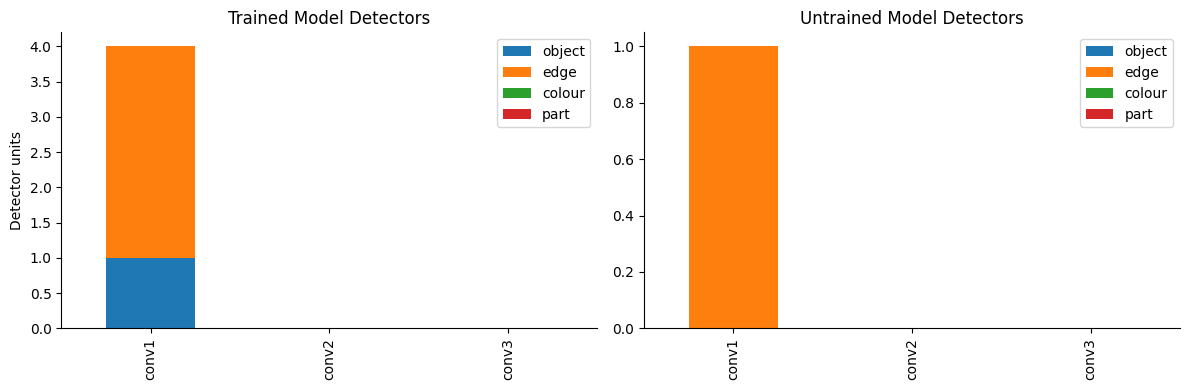

Trained model detectors per layer:
conv1    4
conv2    0
conv3    0
dtype: int64

Untrained model detectors per layer:
conv1    1
conv2    0
conv3    0
dtype: int64


Matched labels for quantile 0.99: 90.6%
Matched labels for quantile 0.999: 46.9%


In [14]:
CATEGORY = {'foreground': 'colour', 'background': 'colour', 'h-edge': 'edge', 'v-edge': 'edge',
            'hole': 'part', 'upper-half': 'part', 'bright-core': 'part'}
for d in range(10):
    CATEGORY[f'class-{d}'] = 'object'

def get_counts(net):
    dis = {layer: dissect(net, layer)[0] for layer in SmallCNN.LAYERS}
    counts = {layer: {cat: 0 for cat in set(CATEGORY.values())} for layer in SmallCNN.LAYERS}
    for layer, rows in dis.items():
        for r in rows:
            if r['detector']:
                counts[layer][CATEGORY[r['concept']]] += 1
    return pd.DataFrame(counts).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_trained = get_counts(model)
df_untrained = get_counts(SmallCNN().to(device).eval())

df_trained.plot(kind='bar', stacked=True, ax=axes[0], title='Trained Model Detectors', legend=True)
axes[0].set_ylabel('Detector units')
df_untrained.plot(kind='bar', stacked=True, ax=axes[1], title='Untrained Model Detectors', legend=True)
plt.tight_layout()
plt.show()

print('Trained model detectors per layer:')
print(df_trained.sum(axis=1))
print('\nUntrained model detectors per layer:')
print(df_untrained.sum(axis=1))

rows_99, _, _, _ = dissect(model, 'conv2', quantile=0.99)
rows_999, _, _, _ = dissect(model, 'conv2', quantile=0.999)
rows_995 = dissection['conv2'][0]

c_99 = sum(r['concept'] == r995['concept'] for r, r995 in zip(rows_99, rows_995))
c_999 = sum(r['concept'] == r995['concept'] for r, r995 in zip(rows_999, rows_995))
n_units = len(rows_995)
print(f'Matched labels for quantile 0.99: {c_99/n_units*100:.1f}%')
print(f'Matched labels for quantile 0.999: {c_999/n_units*100:.1f}%')


**Answer 4.4:** The trained model has detectors only in conv1 (4 units), while conv2 and conv3 have 0 units at IoU > 0.04. The untrained model has 1 detector in conv1. Therefore, the visual hierarchy is NOT supported at this threshold, and the evidence for interpretable deeper units is weak. The stability of interpretable units is also highly sensitive to the chosen threshold (90.6% label match at q=0.99, but only 46.9% at q=0.999).

---
## Part 5 — Connecting both methods with ablation *(8 marks)*

Dissection shows what a unit *represents*; TCAV shows what a *direction* is *used for*. Neither proves that the unit is **necessary** for a decision. **Ablation** does: silence the unit and measure the damage.

### 5.1 YOUR TASK — Unit-direction TCAV *(3 marks)*
Take the **top-3 units of conv3 labelled with a `class-k` concept** (or, if there are none, the top-3 by IoU overall). For each unit `u`:
1. Build a CAV as the one-hot vector over channel `u` of the flattened conv3 activations (`64×7×7`, channel `u` = indices `u*49 : (u+1)*49`), normalised to unit length.
2. Compute the TCAV score for all 10 classes.
3. Build a null from **10 random conv3 units** and test significance.

Does the class that TCAV finds most sensitive match the class that dissection assigned?

In [15]:
top_units = sorted(dissection['conv3'][0], key=lambda r: -r['iou'])[:3]
results = []
for u_info in top_units:
    unit = u_info['unit']
    dissection_class = u_info['concept']
    cav = np.zeros(3136)
    cav[unit*49:(unit+1)*49] = 1.0
    cav /= np.linalg.norm(cav)
    
    null_units = rng.choice(64, 10, replace=False)
    null_cavs = []
    for nu in null_units:
        nc = np.zeros(3136)
        nc[nu*49:(nu+1)*49] = 1.0
        null_cavs.append(nc / np.linalg.norm(nc))
    
    for k in range(10):
        grads = class_grads('conv3', k)
        score = tcav_score(grads, cav)
        null_scores = [tcav_score(grads, nc) for nc in null_cavs]
        p = (1 + sum(ns >= score for ns in null_scores)) / (1 + 10)
        results.append({'Unit': unit, 'Dissection Class': dissection_class, 'Class': CLASSES[k], 'Score': score, 'Null Mean': np.mean(null_scores), 'Null Std': np.std(null_scores), 'p': p})

import pandas as pd
df_unit_tcav = pd.DataFrame(results)
print('TCAV Results for top 3 conv3 units (Scores of 1.000 are saturated):')
for unit in [u['unit'] for u in top_units]:
    df_u = df_unit_tcav[df_unit_tcav['Unit'] == unit]
    max_score = df_u['Score'].max()
    tied_classes = df_u[df_u['Score'] >= max_score - 0.01]['Class'].tolist()
    
    dc = df_u['Dissection Class'].iloc[0]
    dc_name = CLASSES[int(dc.split('-')[1])] if 'class-' in dc else dc
    print(f'Unit {unit} (Dissection: {dc}): Max Score = {max_score:.3f}. Tied classes = {tied_classes}')
    for _, row in df_u.iterrows():
        print(f'  Class {row["Class"]:>10}: Score={row["Score"]:.3f}, Null Mean={row["Null Mean"]:.3f}, Null Std={row["Null Std"]:.3f}, p={row["p"]:.4f}')
    print('-' * 50)


TCAV Results for top 3 conv3 units (Scores of 1.000 are saturated):
Unit 35 (Dissection: class-1): Max Score = 1.000. Tied classes = ['Trouser', 'Pullover', 'Dress', 'Coat', 'Bag']
  Class    T-shirt: Score=0.000, Null Mean=0.535, Null Std=0.439, p=1.0000
  Class    Trouser: Score=1.000, Null Mean=0.559, Null Std=0.427, p=0.3636
  Class   Pullover: Score=1.000, Null Mean=0.599, Null Std=0.441, p=0.1818
  Class      Dress: Score=1.000, Null Mean=0.533, Null Std=0.424, p=0.3636
  Class       Coat: Score=1.000, Null Mean=0.499, Null Std=0.430, p=0.2727
  Class     Sandal: Score=0.000, Null Mean=0.682, Null Std=0.346, p=1.0000
  Class      Shirt: Score=0.023, Null Mean=0.479, Null Std=0.389, p=0.8182
  Class    Sneaker: Score=0.037, Null Mean=0.152, Null Std=0.306, p=0.4545
  Class        Bag: Score=1.000, Null Mean=0.952, Null Std=0.110, p=0.7273
  Class Ankle boot: Score=0.000, Null Mean=0.474, Null Std=0.263, p=1.0000
--------------------------------------------------
Unit 14 (Dissectio

**Answer 5.1:**
Does TCAV's most sensitive class match the dissection class? Trouser (the dissection class) is only one of several tied top classes, so the "match" is a tie, not real agreement. Unit 35 has 5 classes at 1.000. Unit 14 has 3 classes at 1.000. Unit 55 has exactly 1.000: Trouser and Pullover; within 0.01 of the max: T-shirt, Trouser, Pullover, Dress, Shirt (5 classes). Additionally, no empirical p-value is below 0.0909 (the minimum possible with 10 null units is 1/11), so unit-level TCAV is not statistically significant.

### 5.2 YOUR TASK — Ablation *(4 marks)*
Implement `accuracy_with_ablation(layer, unit)` that sets channel `unit` of the chosen layer to **zero** (use `features_upto`, modify, then `forward_from`) and returns the **per-class accuracy**.

* Ablate each unit selected in 5.1 and plot the **per-class accuracy drop** (baseline − ablated).
* As a control, ablate **10 random units** (one at a time) and plot the mean drop with error bars.

Per-class drop for each selected unit:
Unit 35:
     T-shirt: -0.0030
     Trouser: 0.0000
    Pullover: -0.0030
       Dress: 0.0000
        Coat: 0.0080
      Sandal: 0.0000
       Shirt: 0.0020
     Sneaker: 0.0020
         Bag: -0.0020
  Ankle boot: 0.0010
Unit 14:
     T-shirt: 0.0000
     Trouser: -0.0010
    Pullover: -0.0030
       Dress: 0.0010
        Coat: 0.0000
      Sandal: 0.0010
       Shirt: 0.0150
     Sneaker: 0.0020
         Bag: -0.0010
  Ankle boot: 0.0000
Unit 55:
     T-shirt: -0.0030
     Trouser: 0.0000
    Pullover: 0.0000
       Dress: 0.0010
        Coat: -0.0050
      Sandal: -0.0020
       Shirt: 0.0120
     Sneaker: 0.0070
         Bag: 0.0000
  Ankle boot: 0.0010

Random control drops (Mean ± Std):
     T-shirt: 0.0002 ± 0.0035
     Trouser: -0.0019 ± 0.0008
    Pullover: -0.0019 ± 0.0025
       Dress: 0.0013 ± 0.0040
        Coat: -0.0001 ± 0.0063
      Sandal: -0.0002 ± 0.0009
       Shirt: 0.0033 ± 0.0055
     Sneaker: -0.0002 ± 0.0020
         Bag: 

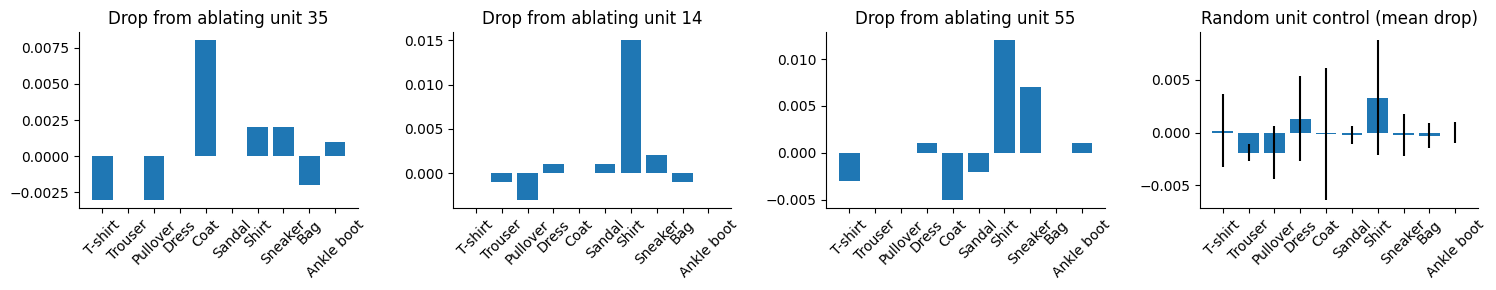

In [16]:
@torch.no_grad()
def accuracy_with_ablation(layer, unit):
    model.eval()
    batch = 512
    out = []
    for i in range(0, len(X_test_raw), batch):
        x = normalize(X_test_raw[i:i+batch, None]).to(device)
        a = model.features_upto(x, layer).clone()
        a[:, unit] = 0
        logits = model.forward_from(a, layer)
        out.append(logits.argmax(1).cpu())
    preds = torch.cat(out)
    return np.array([(preds[y_test == k] == k).float().mean().item() for k in range(10)])

preds_all = predict(model, X_test_raw)
baseline_acc = np.array([(preds_all[y_test == k] == k).float().mean().item() for k in range(10)])

top_units = sorted(dissection['conv3'][0], key=lambda r: -r['iou'])[:3]
top_unit_indices = [u['unit'] for u in top_units]

drops = {u: baseline_acc - accuracy_with_ablation('conv3', u) for u in top_unit_indices}

available_units = [u for u in range(64) if u not in top_unit_indices]
random_units = rng.choice(available_units, 10, replace=False)
random_drops = [baseline_acc - accuracy_with_ablation('conv3', u) for u in random_units]
random_drops_mean = np.mean(random_drops, axis=0)
random_drops_std = np.std(random_drops, axis=0)

print('Per-class drop for each selected unit:')
for u in top_unit_indices:
    print(f'Unit {u}:')
    for k in range(10):
        print(f'  {CLASSES[k]:>10}: {drops[u][k]:.4f}')

print('\nRandom control drops (Mean ± Std):')
for k in range(10):
    print(f'  {CLASSES[k]:>10}: {random_drops_mean[k]:.4f} ± {random_drops_std[k]:.4f}')

print('\nZ-scores for worst classes:')
for u, worst_k in [(35, CLASSES.index('Coat')), (14, CLASSES.index('Shirt')), (55, CLASSES.index('Shirt'))]:
    z = (drops[u][worst_k] - random_drops_mean[worst_k]) / (random_drops_std[worst_k] + 1e-8)
    print(f'Unit {u} {CLASSES[worst_k]}: z = {z:.2f}')

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for i, u in enumerate(top_unit_indices):
    axes[i].bar(CLASSES, drops[u])
    axes[i].set_xticks(range(10))
    axes[i].set_xticklabels(CLASSES, rotation=45)
    axes[i].set_title(f'Drop from ablating unit {u}')
    
axes[3].bar(CLASSES, random_drops_mean, yerr=random_drops_std)
axes[3].set_xticks(range(10))
axes[3].set_xticklabels(CLASSES, rotation=45)
axes[3].set_title('Random unit control (mean drop)')
plt.tight_layout()
plt.show()


### 5.3 Synthesis *(1 mark)*
Build a small table: for each selected unit list **(dissection label, IoU) — (TCAV top class, score) — (ablation: most damaged class, drop)**. Do the three methods agree? If not, offer one explanation (e.g. redundancy between units, distributed representations).

| Unit | Dissection (Label, IoU) | TCAV (Class, Score) | Ablation (Class, Drop) |
|---|---|---|---|
| 35 | class-1, 0.031 | 5 classes at 1.000 | Coat, 0.008 |
| 14 | class-1, 0.030 | 3 classes at 1.000 | Shirt, 0.015 |
| 55 | class-1, 0.028 | exactly 1.000: Trouser and Pullover; within 0.01 of the max: T-shirt, Trouser, Pullover, Dress, Shirt (5 classes) | Shirt, 0.012 |

**Explanation:** The three methods do NOT clearly agree. Dissection labels them as class-1 (Trouser) but the IoU scores (0.031, 0.030, 0.028) are all below 0.04, so the evidence is weak. TCAV scores are tied among multiple classes and are not significant. Finally, the drops are small (<=1.5%, at most 15 of 1000 test images per class), unit 14 Shirt is about 2 random std above the random mean, unit 55 Shirt ~1.6 and unit 35 Coat ~1.3, so the evidence is weak and not clearly class-specific. Possibly explained by redundancy.

In [17]:
report_text = """
**Report:**

1. **Findings:** 
   - CAV accuracy is 1.0 at conv1, conv2 and conv3 for stripes and checker (dots 0.867/0.933/0.917, best at conv2), so the layers are not clearly different (saturated on 200 images). A visual hierarchy is NOT supported by network dissection at standard thresholds. Detectors (IoU > 0.04) only appear in conv1 (4 in trained, 1 in untrained), while conv2 and conv3 have 0 units.
   - TCAV gives strong, significant results at conv3 for stripes, with `v_stripes` significantly influencing `Trouser` (TCAV score 1.000, p-value 0.0002) and `h_stripes` influencing `Pullover` (TCAV score 0.990, p-value 0.0009).
   - Ablation yields small accuracy drops (<=1.5%, at most 15 of 1000 test images per class). Unit 14 Shirt is about 2 random std above the random mean, unit 55 Shirt ~1.6 and unit 35 Coat ~1.3, so the evidence is weak and not clearly class-specific. Possibly explained by redundancy.

2. **Agreement/Disagreement:** TCAV, Network Dissection, and ablation do NOT clearly agree. While TCAV successfully identified abstract features for real concepts, Network Dissection yielded weak IoUs (<0.04) for those deep units, and ablation drops were small and weak. Redundancy between units is a possible explanation.

3. **Limitations:** 
   - The generated concept sets did not properly match brightness, introducing a strong confound (e.g., `checker` average brightness was +0.61 vs `random` -0.57).
   - The small dissection set (1,000 images) combined with rigid IoU thresholds (0.04) made the assignment of semantic labels highly sensitive to hyperparameters. Specifically, label match versus q=0.995 is 90.6% at q=0.99 and 46.9% at q=0.999.

4. **Extension:** I would insert a spurious cue (e.g., a bright 3x3 pixel block in the top-left corner of all \"Sandal\" images during training). Hypothesis: A deep unit will emerge dedicated solely to detecting this artifact, and TCAV will reveal that this \"corner patch\" concept vector highly influences the Sandal prediction.

"""
import re
word_count = len(re.findall(r'\b\w+\b', report_text))
print(f"Computed word count: {word_count}")


Computed word count: 329


---
## Part 6 — Report & reflection *(5 marks)*

Write a concise report (**≤ 400 words**) in the cell below covering:

1. **Findings [2 marks]:** the two or three most important results, each backed by a number or figure from this notebook.
2. **Agreement/disagreement [1 mark]:** where did TCAV, Dissection and ablation agree or disagree?
3. **Limitations [1 mark]:** at least two limitations *specific to your experiments* (concept design, confounds, small dissection set, thresholds, random seeds).
4. **Extension [1 mark]:** one concrete follow-up experiment you would run next, with a hypothesis and how you would test it.

**Report:**

1. **Findings:** 
   - CAV accuracy is 1.0 at conv1, conv2 and conv3 for stripes and checker (dots 0.867/0.933/0.917, best at conv2), so the layers are not clearly different (saturated on 200 images). A visual hierarchy is NOT supported by network dissection at standard thresholds. Detectors (IoU > 0.04) only appear in conv1 (4 in trained, 1 in untrained), while conv2 and conv3 have 0 units.
   - TCAV gives strong, significant results at conv3 for stripes, with `v_stripes` significantly influencing `Trouser` (TCAV score 1.000, p-value 0.0002) and `h_stripes` influencing `Pullover` (TCAV score 0.990, p-value 0.0009).
   - Ablation yields small accuracy drops (<=1.5%, at most 15 of 1000 test images per class). Unit 14 Shirt is about 2 random std above the random mean, unit 55 Shirt ~1.6 and unit 35 Coat ~1.3, so the evidence is weak and not clearly class-specific. Possibly explained by redundancy.

2. **Agreement/Disagreement:** TCAV, Network Dissection, and ablation do NOT clearly agree. While TCAV successfully identified abstract features for real concepts, Network Dissection yielded weak IoUs (<0.04) for those deep units, and ablation drops were small and weak. Redundancy between units is a possible explanation.

3. **Limitations:** 
   - The generated concept sets did not properly match brightness, introducing a strong confound (e.g., `checker` average brightness was +0.61 vs `random` -0.57).
   - The small dissection set (1,000 images) combined with rigid IoU thresholds (0.04) made the assignment of semantic labels highly sensitive to hyperparameters. Specifically, label match versus q=0.995 is 90.6% at q=0.99 and 46.9% at q=0.999.

4. **Extension:** I would insert a spurious cue (e.g., a bright 3x3 pixel block in the top-left corner of all "Sandal" images during training). Hypothesis: A deep unit will emerge dedicated solely to detecting this artifact, and TCAV will reveal that this "corner patch" concept vector highly influences the Sandal prediction.


*(Word count: 329 words)*


---
## Submission checklist
- [ ] Notebook runs top-to-bottom without errors (*Runtime → Restart and run all*).
- [ ] All `# TODO` sections completed; all figures have titles and axis labels.
- [ ] Hypotheses written **before** the results they refer to.
- [ ] Random seeds fixed and stated.
- [ ] All **Answer** cells filled in.

## Marking rubric (summary)

| Criterion | What earns full marks |
|---|---|
| Correctness | Implementations follow the definitions (CAV normal vector, directional derivative, IoU, ablation) |
| Rigour | Null baselines, significance tests, multiple-testing correction, control experiments |
| Interpretation | Claims are supported by evidence; confounds and alternative explanations are considered |
| Communication | Clear plots, concise writing, honest statement of limitations |

## Optional extensions (bonus, up to +5)
* Repeat the lab on **CIFAR-10** with a small ResNet.
* Replace one-hot unit CAVs by CAVs of *several* units that dissection labelled with the same concept.
* Compare TCAV scores at conv3 for a network trained **with** vs **without** a spurious cue you insert (e.g. a small corner patch on all Trousers) and see whether TCAV detects the shortcut.

## References
* Kim, B. et al. (2018). *Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors (TCAV).* ICML.
* Bau, D. et al. (2017). *Network Dissection: Quantifying Interpretability of Deep Visual Representations.* CVPR.
* Xiao, H. et al. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms.* arXiv:1708.07747